We are creating an email classification system, the lets you classify your email into 4 categories (spam, important, social and promotions).
The dataset contains 1M rows across six categories but we used 400k emails with four classes, beacuse of limited storage and time.
 
Dataset_link: https://www.kaggle.com/datasets/sharmajicoder/email-spam-classification

step 1: importing all the required libraries

In [1]:
# impprting all the required libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize
from nltk import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')

#remove the warnings
import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package stopwords to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


step 2: imorting data, checking and removing duplicates and missing values from the data

First 5 rows of dataset:
       label                                               text
0  important  Let's catch up Although again development inte...
1  important  Let's catch up Organization why economy list w...
2  important  Let's catch up Relationship just discuss miss....
3     social  Someone liked your post General way training w...
4  promotion  Discount just for you Too visit money consumer...

Label Distribution:
label
important    100000
social       100000
promotion    100000
spam         100000
Name: count, dtype: int64


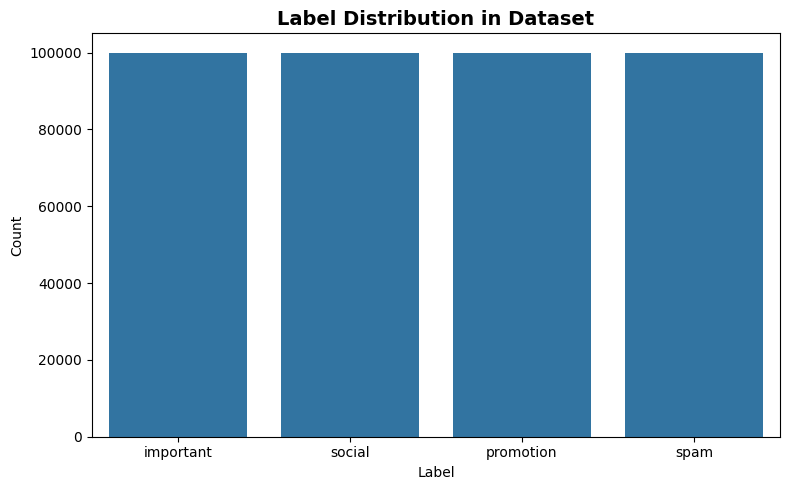

In [2]:
# Function to load and explore the dataset
def load_dataset(file_path):
    """
    Load and perform initial exploration of the dataset
    """
    # upload the dataset
    df = pd.read_csv(file_path)
    
    #check the first few rows of the dataset
    print("First 5 rows of dataset:")
    print(df.head())
    
    # check the label distribution
    print("\nLabel Distribution:")
    print(df['label'].value_counts())
    
    # plot the label distribution with default colors
    plt.figure(figsize=(8, 5))
    sns.countplot(x='label', data=df)
    plt.title('Label Distribution in Dataset', fontsize=14, fontweight='bold')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('figures/label_distribution.png')
    plt.show()
    
    return df

# Load dataset
df = load_dataset('email_classifier_dataset.csv')

Step 3: Cleaning the data by removing missing and duplicated values and cheking the distribution of the data.


Missing Values:
label    0
text     0
dtype: int64

Missing Values After Cleaning:
label    0
text     0
dtype: int64

Duplicate rows found: 0
Duplicates after removal: 0

First 5 rows after cleaning:
       label                                               text
0  important  Let's catch up Although again development inte...
1  important  Let's catch up Organization why economy list w...
2  important  Let's catch up Relationship just discuss miss....
3     social  Someone liked your post General way training w...
4  promotion  Discount just for you Too visit money consumer...


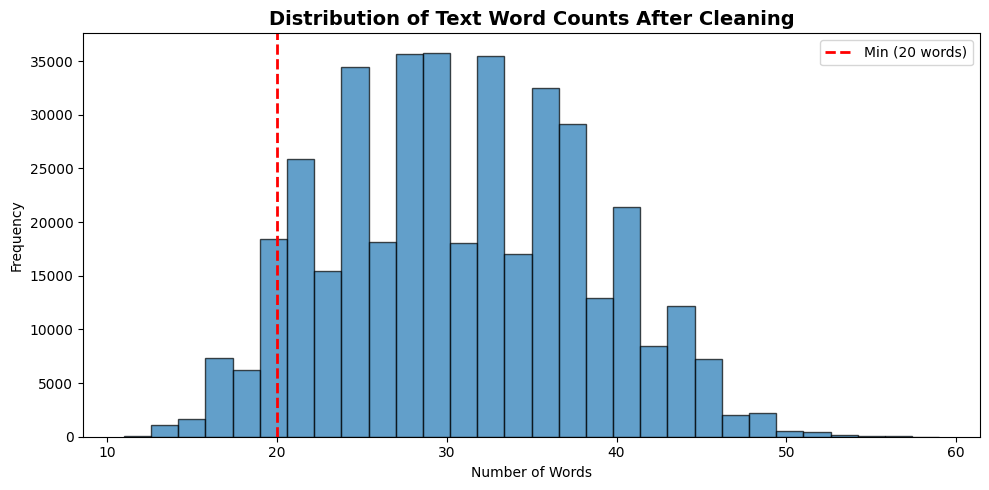

In [5]:
# perform data cleaning before preprocessing and training the models
def clean_dataset(df):
    """
    Clean the dataset by handling missing values, duplicates, and filtering reviews
    """
    # checking for missing values
    print("Missing Values:")
    print(df.isnull().sum())
    
    # since we got some missing values in the Text column, we will drop those rows
    df.dropna(subset=['text'], inplace=True)
    
    #again check for missing values
    print("\nMissing Values After Cleaning:")
    print(df.isnull().sum())
    
    #checking for duplicates
    print(f"\nDuplicate rows found: {df.duplicated().sum()}")
    
    #we also got some duplicate rows, we will drop those as well
    df.drop_duplicates(inplace=True)
    
    #again check for duplicates
    print(f"Duplicates after removal: {df.duplicated().sum()}")
    
    #checking the head of the dataset after preprocessing
    print("\nFirst 5 rows after cleaning:")
    print(df.head())
    
    # Visualize Text length distribution after cleaning
    plt.figure(figsize=(10, 5))
    plt.hist(df['text'].apply(lambda x: len(str(x).split())), bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(x=20, color='red', linestyle='--', linewidth=2, label='Min (20 words)')
    plt.title('Distribution of Text Word Counts After Cleaning', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.savefig('figures/Text_length_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return df

# Clean dataset (before preprocessing)
df = clean_dataset(df)

step 4: preprocessing the dataset for better model training and accuracy

In [7]:
# preprocess the text data using advance text cleaning techniques to improve the performance of the models
# Load stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Advanced NLP preprocessing pipeline:
    - Lowercasing
    - Remove URLs and HTML tags
    - Normalize currency and numbers
    - Remove special characters
    - Tokenization (NLTK)
    - POS tagging
    - Lemmatization with POS
    - Stopword removal
    - Remove short tokens
    - Clean extra spaces
    """
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # 3. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # 4. Normalize currency (e.g., $100.50 → money)
    text = re.sub(r'\$\s?\d+(\.\d+)?', ' money ', text)
    
    # 5. Normalize numbers (e.g., 123 → number)
    text = re.sub(r'\d+(\.\d+)?', ' number ', text)
    
    # 6. Remove special characters & punctuation
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # 7. Tokenization using NLTK
    tokens = word_tokenize(text)
    
    # 8. POS tagging
    pos_tags = pos_tag(tokens)
    
    # 9. Helper function for POS conversion (inside function as requested)
    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return 'a'  # adjective
        elif tag.startswith('V'):
            return 'v'  # verb
        elif tag.startswith('N'):
            return 'n'  # noun
        elif tag.startswith('R'):
            return 'r'  # adverb
        else:
            return 'n'
    
    # 10. Lemmatization + stopword removal + short word filtering
    cleaned_words = []
    for word, tag in pos_tags:
        if word not in stop_words and len(word) > 2:
            pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos)
            cleaned_words.append(lemma)
    
    # 11. Join tokens
    text = ' '.join(cleaned_words)
    
    # 12. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# apply the preprocessing function to the reviews
print("Applying text preprocessing...")
df['text'] = df['text'].apply(preprocess_text)


# Remove any empty strings after preprocessing
df = df[df['text'].str.strip() != ""]

# check the length and sample of the dataset after preprocessing
print("Text preprocessing completed!")
print(f"Number of reviews after preprocessing: {len(df)}")
print("\nSample preprocessed text:")
print(df['text'].iloc[0][:200] + "...")

Applying text preprocessing...
Text preprocessing completed!
Number of reviews after preprocessing: 400000

Sample preprocessed text:
let catch although development international really civil season thousand remember structure top throw pretty suggest note human rich lose explain job store around free seek behind inside staff develo...


step 5: Feature engineering, dividing the data into target and features variable for training and apply label encoder to the target column

In [8]:
# Prepare features using TF-IDF and labels using LabelEncoder
def prepare_features(df):
    """
    Prepare features using TF-IDF and labels using LabelEncoder
    """
    # now we will split the dataset into features and target variable
    X = df['text']  # Features (reviews)
    y = df['label']  # Target variable (sentiment)
    
    # we will convert the target variable into numerical format using LabelEncoder and save the encoder for later use
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)
    
    # lets see the mapping of the labels
    label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    print("Label Mapping:", label_mapping)
    
    # checking the shape of the features and target variable
    print("Features shape:", X.shape)
    print("Target variable shape:", y.shape)
    
    # apply TFIDF vectorization to convert text data into numerical format
    vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=15000,
    max_df=0.90,
    min_df=3,
    sublinear_tf=True,
    strip_accents='unicode'
)

    X = vectorizer.fit_transform(df['text'])

    print("\nFeature Matrix Shape:", X.shape)
    print("\nTarget Vector Shape:", y.shape)
    
    # train test split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    print(f"\nTraining set size: {X_train.shape}")
    print(f"Test set size: {X_test.shape}")
    
    return X_train, X_test, y_train, y_test, vectorizer, label_encoder

# Prepare features
X_train, X_test, y_train, y_test, vectorizer, label_encoder = prepare_features(df)

Label Mapping: {'important': 0, 'promotion': 1, 'social': 2, 'spam': 3}
Features shape: (400000,)
Target variable shape: (400000,)

Feature Matrix Shape: (400000, 15000)

Target Vector Shape: (400000,)

Training set size: (320000, 15000)
Test set size: (80000, 15000)


step 6: Training differnt models on the same data and to see which model works best so that we can use it further.

In [9]:
#Training different models and finding the best one

def get_models():
    """
    Define models and their hyperparameters
    """
    models = {
        'Logistic Regression': {
            'model': LogisticRegression(
                max_iter=500,
                class_weight='balanced',
                solver='lbfgs',
            ),
            'params': {
                'C': [0.1, 1, 10]
            }
        },
        'Naive Bayes': {
            'model': MultinomialNB(),
            'params': {
                'alpha': [0.1, 0.5, 1.0]
            }
        },
        'Linear SVM': {
            'model': CalibratedClassifierCV(
                LinearSVC(max_iter=2000)
            ),
            'params': {
                'estimator__C': [0.1, 1, 10]
            }
        }
    }
    return models

# Train and evaluate models
def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    """
    Train and evaluate multiple models, return the best model and results
    """
    models = get_models()
    results = {}
    trained_models = {}
    best_f1 = 0
    best_model = None
    best_model_name = ""
    
    # loop through each model, perform hyperparameter tuning, and evaluate performance
    for name, config in models.items():
        print(f"\n📊 Training {name}...")
        
        random_search = RandomizedSearchCV(
            estimator=config['model'],
            param_distributions=config['params'],
            n_iter=3,
            scoring='f1_weighted',
            cv=3,
            random_state=42,
            n_jobs=-1,
            verbose=0
        )
        
        # fit the model and evaluate performance
        random_search.fit(X_train, y_train)
        trained_model = random_search.best_estimator_
        y_pred = trained_model.predict(X_test)
        
        # calculate evaluation metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results[name] = {
            'Accuracy': round(accuracy, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1 Score': round(f1, 4),
            'Best Params': random_search.best_params_
        }
        
        trained_models[name] = trained_model
        
        if f1 > best_f1:
            best_f1 = f1
            best_model = trained_model
            best_model_name = name
        
        print(f"   ✅ F1 Score: {f1:.4f}")
    
    print(f"\n🏆 BEST MODEL: {best_model_name} (F1: {best_f1:.4f})")
    
    # create the comparison table
    results_df = pd.DataFrame(results).T
    results_df = results_df.sort_values(by='F1 Score', ascending=False)
    
    print("\nMODEL COMPARISON RESULTS")
    print(results_df)
    print("\nBEST MODEL")
    print(f"Best Model: {best_model_name}")
    print(f"Best F1 Score: {best_f1:.4f}")
    
    return best_model, results_df

# Execute training
best_model, results_df = train_and_evaluate_models(X_train, X_test, y_train, y_test)


📊 Training Logistic Regression...
   ✅ F1 Score: 1.0000

📊 Training Naive Bayes...
   ✅ F1 Score: 0.9995

📊 Training Linear SVM...
   ✅ F1 Score: 1.0000

🏆 BEST MODEL: Logistic Regression (F1: 1.0000)

MODEL COMPARISON RESULTS
                    Accuracy Precision  Recall F1 Score            Best Params
Logistic Regression      1.0       1.0     1.0      1.0              {'C': 10}
Linear SVM               1.0       1.0     1.0      1.0  {'estimator__C': 0.1}
Naive Bayes           0.9995    0.9995  0.9995   0.9995         {'alpha': 1.0}

BEST MODEL
Best Model: Logistic Regression
Best F1 Score: 1.0000


step 7: Saving all the models for later use

In [10]:
# Saving all the models for later use

def save_models(best_model, vectorizer, label_encoder):
    """
    Save trained models and preprocessing objects
    """
    os.makedirs('models', exist_ok=True)
    
    with open("models/best_model.pkl", "wb") as f:
        pickle.dump(best_model, f)
    with open("models/vectorizer.pkl", "wb") as f:
        pickle.dump(vectorizer, f)
    with open("models/label_encoder.pkl", "wb") as f:
        pickle.dump(label_encoder, f)
    
    print("✅ Models saved")
    print("- models/best_model.pkl")
    print("- models/vectorizer.pkl")
    print("- models/label_encoder.pkl")

# Execute save
save_models(best_model, vectorizer, label_encoder)

✅ Models saved
- models/best_model.pkl
- models/vectorizer.pkl
- models/label_encoder.pkl


step 8: visualization of confusion matrix, model comparsion bar chart, perclass performance mertices and ROC Curves for each class for better understanding.

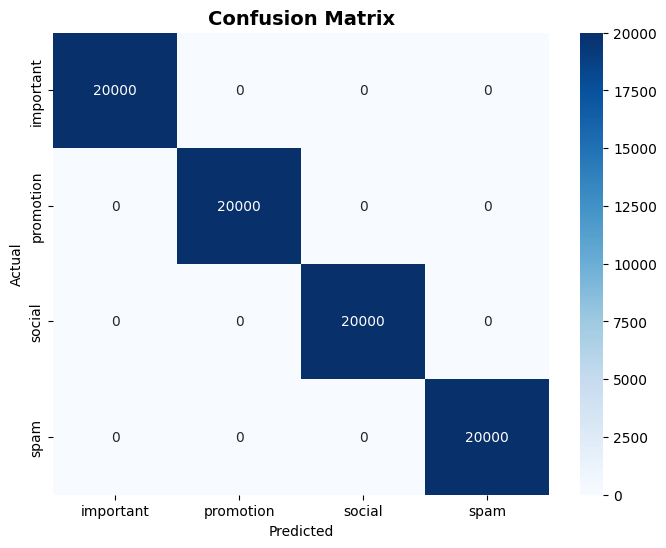


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

   important       1.00      1.00      1.00     20000
   promotion       1.00      1.00      1.00     20000
      social       1.00      1.00      1.00     20000
        spam       1.00      1.00      1.00     20000

    accuracy                           1.00     80000
   macro avg       1.00      1.00      1.00     80000
weighted avg       1.00      1.00      1.00     80000



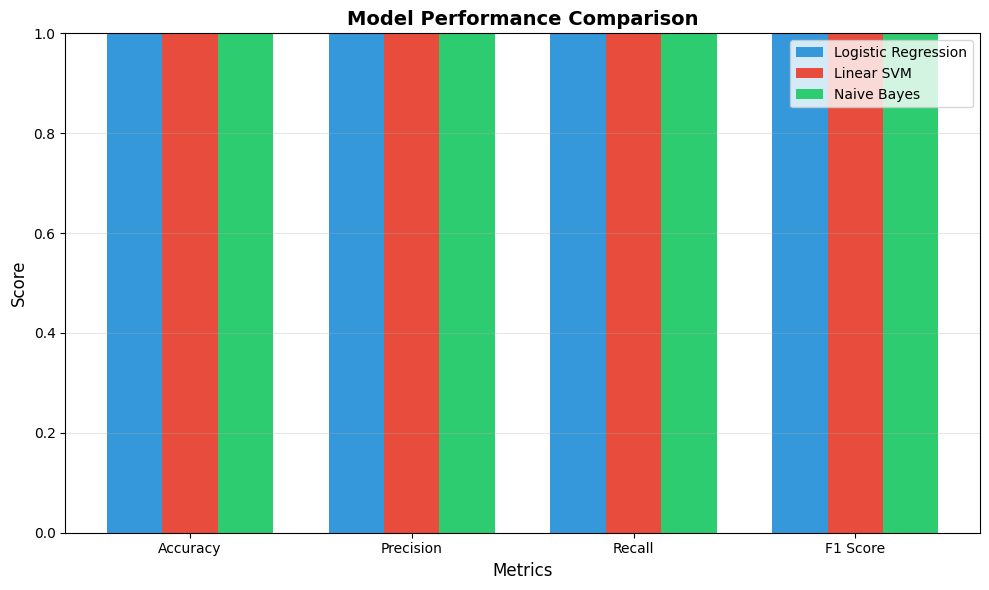

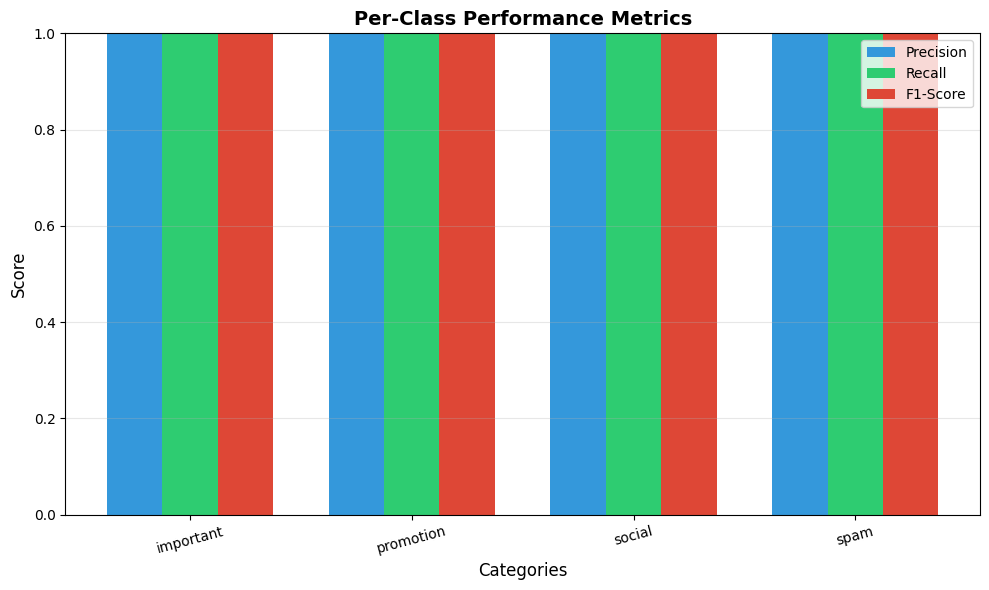

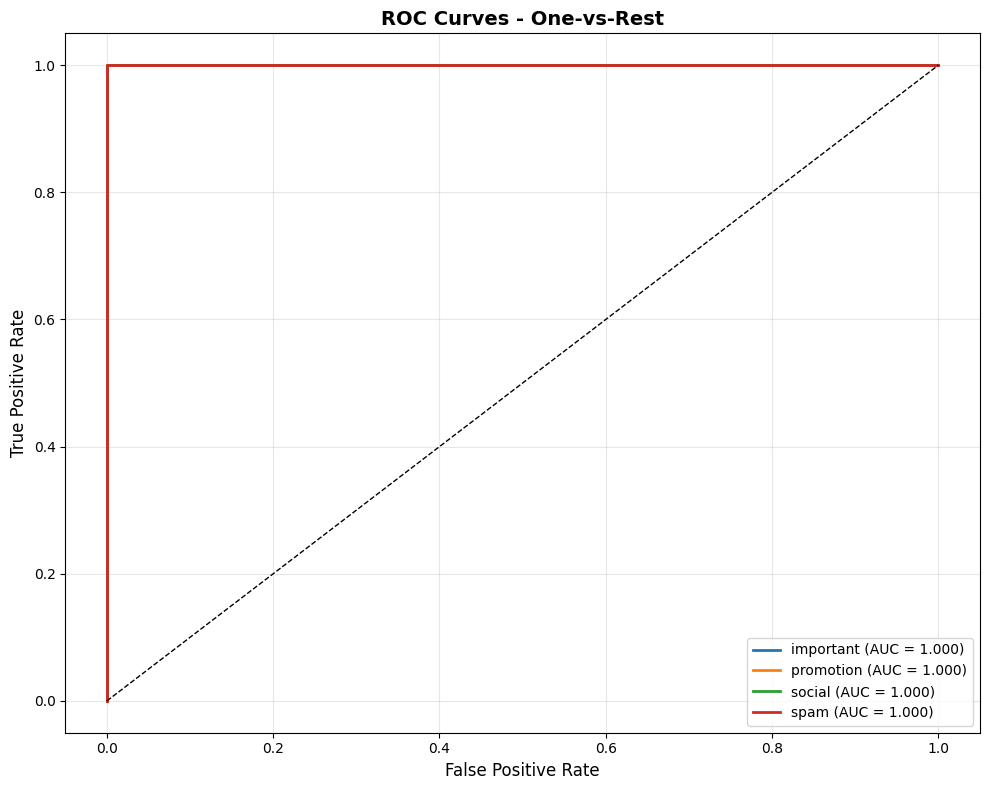

In [11]:
# Step 10: Visualization of confusion matrix, model comparison, per-class metrics and ROC Curves

# Function to plot confusion matrix and classification report for the best model
def plot_confusion_matrix(best_model, X_test, y_test, label_encoder):
    """
    Plot confusion matrix for the best model
    """
    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('figures/confusion_matrix.png', dpi=150)
    plt.show()
    
    print("\n📋 CLASSIFICATION REPORT:")
    print("="*50)
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    return y_pred

# Plotting functions for model comparison, per-class performance, and ROC curves
def plot_model_comparison(results_df):
    """
    Plot bar chart comparing all models
    """
    plt.figure(figsize=(10, 6))
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    x = np.arange(len(metrics))
    width = 0.25
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    for i, (model_name, scores) in enumerate(results_df.iterrows()):
        values = [scores[m] for m in metrics]
        plt.bar(x + i*width, values, width, label=model_name, color=colors[i])
    
    plt.xlabel('Metrics', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
    plt.xticks(x + width, metrics)
    plt.legend()
    plt.ylim(0, 1)
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('figures/model_comparison.png', dpi=150)
    plt.show()

# Plot per-class precision, recall, and f1-score
def plot_per_class_performance(best_model, X_test, y_test, label_encoder):
    """
    Plot per-class precision, recall, and f1-score
    """
    y_pred = best_model.predict(X_test)
    precision, recall, fscore, support = precision_recall_fscore_support(y_test, y_pred)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(label_encoder.classes_))
    width = 0.25
    
    ax.bar(x - width, precision, width, label='Precision', color='#3498db')
    ax.bar(x, recall, width, label='Recall', color='#2ecc71')
    ax.bar(x + width, fscore, width, label='F1-Score', color="#de4736")
    
    ax.set_xlabel('Categories', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(label_encoder.classes_, rotation=15)
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('figures/per_class_performance.png', dpi=150)
    plt.show()

# Plot ROC curves for each class
def plot_roc_curves(best_model, X_test, y_test, label_encoder):
    """
    Plot ROC curves for each class
    """
    if hasattr(best_model, 'predict_proba'):
        plt.figure(figsize=(10, 8))
        y_prob = best_model.predict_proba(X_test)
        
        for i, category in enumerate(label_encoder.classes_):
            fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{category} (AUC = {roc_auc:.3f})', linewidth=2)
        
        plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title('ROC Curves - One-vs-Rest', fontsize=14, fontweight='bold')
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('figures/roc_curves.png', dpi=150)
        plt.show()

# Execute visualizations
y_pred = plot_confusion_matrix(best_model, X_test, y_test, label_encoder)
plot_model_comparison(results_df)
plot_per_class_performance(best_model, X_test, y_test, label_encoder)
plot_roc_curves(best_model, X_test, y_test, label_encoder)

step 9: Top keywords per category to visualize the most import features of each class.

In [12]:
# Top keywords per category to visualize the most important features for each class based on the coefficients of the best model.

def display_top_keywords(best_model, vectorizer, label_encoder):
    """
    Display top keywords for each category
    """
    feature_names = vectorizer.get_feature_names_out()
    
    if hasattr(best_model, 'coef_'):
        print("\n" + "="*50)
        print("TOP KEYWORDS PER CATEGORY")
        print("="*50)
        for i, category in enumerate(label_encoder.classes_):
            coef = best_model.coef_[i]
            top_idx = np.argsort(coef)[-10:][::-1]
            top_words = [feature_names[idx] for idx in top_idx]
            print(f"\n{category}: {', '.join(top_words)}")

# Execute
display_top_keywords(best_model, vectorizer, label_encoder)


TOP KEYWORDS PER CATEGORY

important: let catch, tomorrow, project update, update, meeting tomorrow, catch, let, project, meeting, meet tomorrow

promotion: exclusive, exclusive offer, miss exclusive, miss, offer, discount, special offer, offer inside, sale today, big sale

social: notification, check notification, check, friend request, request, new friend, like post, post, someone like, friend

spam: limited, limited time, time offer, iphone, free iphone, win free, win, free, time, winwinwin


step 10: prediction system 

In [13]:
# Prediction function with improved short/long text handling.

def prediction_system(best_model, vectorizer, label_encoder, preprocess_text):
    """
    Create a prediction function with confidence scoring
    """
    def predict_email(text, threshold=0.6):
        """
        Predict email category with confidence score
        Handles short and long texts appropriately
        """
        # Handle empty input
        if not text or str(text).strip() == "":
            return {
                'category': 'ERROR', 
                'confidence': 0.0, 
                'display': '❌ ERROR', 
                'message': 'Empty input'
            }
        
        # Handle very short text (< 10 chars)
        if len(text.strip()) < 10:
            return {
                'category': 'UNCERTAIN', 
                'confidence': 0.0, 
                'display': '⚠️ UNCERTAIN', 
                'message': f'Text too short (minimum 10 characters needed). You entered {len(text.strip())} characters.'
            }
        
        # Handle long text (> 5000 chars) - truncate
        if len(text) > 5000:
            text = text[:5000]
        
        # Preprocess
        cleaned = preprocess_text(text)
        
        if len(cleaned.split()) < 2:
            return {
                'category': 'UNCERTAIN', 
                'confidence': 0.0, 
                'display': '⚠️ UNCERTAIN', 
                'message': 'Text quality too low after preprocessing'
            }
        
        # Vectorize and predict
        X_input = vectorizer.transform([cleaned])
        
        pred = best_model.predict(X_input)[0]
        proba = best_model.predict_proba(X_input)[0]
        confidence = max(proba)
        
        # Apply threshold
        if confidence < threshold:
            category = "UNCERTAIN"
            message = f"Low confidence prediction ({confidence:.1%} < {threshold:.0%})"
        else:
            category = label_encoder.inverse_transform([pred])[0]
            message = None
        
        # Add emoji for display
        emoji_map = {
            'Spam': '🚫', 
            'Promotion': '📢', 
            'Social': '👥', 
            'Important': '⭐', 
            'UNCERTAIN': '⚠️',
            'ERROR': '❌'
        }
        
        return {
            'category': category,
            'display': f"{emoji_map.get(category, '')} {category}",
            'confidence': confidence,
            'message': message,
            'all_probabilities': {label_encoder.classes_[i]: float(p) for i, p in enumerate(proba)}
        }
    
    return predict_email

# Create prediction function
predict_email = prediction_system(best_model, vectorizer, label_encoder, preprocess_text)

# Test the function with various inputs
def test_prediction_system(predict_email):
    """
    Test the prediction system with sample inputs
    """
    print("\n" + "="*50)
    print("📝 TESTING PREDICTION FUNCTION")
    print("="*50)
    
    test_cases = [
        ("", "Empty"),
        ("Hi", "Very Short"),
        ("WINNER! You won $1000! Click here!!!", "Spam"),
        ("FLAT 50% OFF on all products! Limited time!", "Promotion"),
        ("Your friend John commented on your photo", "Social"),
        ("Meeting scheduled for tomorrow at 10 AM", "Important"),
        ("A" * 6000, "Very Long")
    ]
    
    for text, description in test_cases:
        result = predict_email(text)
        status = "⚠️" if result['confidence'] < 0.6 else "✅"
        
        display_text = text[:40] + "..." if len(text) > 40 else text
        if not text:
            display_text = "[Empty]"
        
        print(f"\n{status} {description}:")
        print(f"   Input: {display_text}")
        print(f"   Result: {result['display']}")
        print(f"   Confidence: {result['confidence']:.2%}")
        if result['message']:
            print(f"   Note: {result['message']}")

# Execute test
test_prediction_system(predict_email)


📝 TESTING PREDICTION FUNCTION

⚠️ Empty:
   Input: [Empty]
   Result: ❌ ERROR
   Confidence: 0.00%
   Note: Empty input

⚠️ Very Short:
   Input: Hi
   Result: ⚠️ UNCERTAIN
   Confidence: 0.00%
   Note: Text too short (minimum 10 characters needed). You entered 2 characters.

✅ Spam:
   Input: WINNER! You won $1000! Click here!!!
   Result:  spam
   Confidence: 99.14%

✅ Promotion:
   Input: FLAT 50% OFF on all products! Limited ti...
   Result:  spam
   Confidence: 99.97%

✅ Social:
   Input: Your friend John commented on your photo
   Result:  social
   Confidence: 100.00%

✅ Important:
   Input: Meeting scheduled for tomorrow at 10 AM
   Result:  important
   Confidence: 100.00%

⚠️ Very Long:
   Input: AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...
   Result: ⚠️ UNCERTAIN
   Confidence: 0.00%
   Note: Text quality too low after preprocessing


step 11: Batch prediction system for CSV files etc

In [14]:
#Batch prediction system with progress indicator.

def batch_predictor(predict_email):
    """
    Create batch prediction function
    """
    def batch_predict(input_file, output_file, threshold=0.6):
        """
        Batch predict emails from CSV file
        Shows progress and handles errors gracefully
        """
        if not os.path.exists(input_file):
            print(f"❌ File not found: {input_file}")
            return None
        
        # Load CSV
        df = pd.read_csv(input_file)
        print(f"\n📊 Loaded {len(df)} rows from {input_file}")
        
        # Check for text column
        if 'text' not in df.columns:
            print("❌ CSV must have a 'text' column")
            print(f"   Available columns: {df.columns.tolist()}")
            return None
        
        # Process each row with progress
        results = []
        total = len(df)
        
        print("\n⏳ Processing emails...")
        for idx, text in enumerate(df['text'], 1):
            result = predict_email(str(text), threshold)
            results.append(result)
            
            # Show progress every 100 rows
            if idx % 100 == 0 or idx == total:
                print(f"   Progress: {idx}/{total} ({idx/total*100:.1f}%)")
        
        # Add results to dataframe
        df['prediction'] = [r['category'] for r in results]
        df['confidence'] = [r['confidence'] for r in results]
        df['display'] = [r['display'] for r in results]
        
        # Save to CSV
        df.to_csv(output_file, index=False)
        
        # Print summary
        print(f"\n✅ Results saved to: {output_file}")
        print("\n📊 SUMMARY:")
        print(f"   Total emails: {len(df)}")
        print(f"   ✅ Important: {(df['prediction'] == 'Important').sum()}")
        print(f"   👥 Social: {(df['prediction'] == 'Social').sum()}")
        print(f"   📢 Promotion: {(df['prediction'] == 'Promotion').sum()}")
        print(f"   🚫 Spam: {(df['prediction'] == 'Spam').sum()}")
        print(f"   ⚠️ Uncertain: {(df['prediction'] == 'UNCERTAIN').sum()}")
        print(f"   ❌ Errors: {(df['prediction'] == 'ERROR').sum()}")
        print(f"   Average confidence: {df['confidence'].mean():.2%}")
        
        return df
    
    return batch_predict

# Create batch predictor
batch_predict = batch_predictor(predict_email)

step 12: CLI meanu

In [15]:
#Complete CLI Menu System

def cli_menu(predict_email, batch_predict, results_df, best_model, vectorizer, label_encoder):
    """
    Create interactive CLI menu
    """
    def main_menu():
        """Interactive CLI menu with all features"""
        current_threshold = 0.6
        
        while True:
            print("\n" + "="*50)
            print("📧 EMAIL CLASSIFICATION SYSTEM")
            print("="*50)
            print(" 1. 🔍 Classify Single Email")
            print(" 2. 📁 Batch Process CSV File")
            print(" 3. 📊 View Model Performance")
            print(" 4. 🔑 View Top Keywords per Category")
            print(" 5. ⚙️  Change Confidence Threshold")
            print(" 6. 🧪 Test with Sample Emails")
            print(" 7. ❌ Exit")
            print("="*50)
            
            choice = input("\n👉 Enter choice (1-7): ").strip()
            
            if choice == '1':
                print("\n" + "-"*40)
                text = input("📧 Enter email content: ").strip()
                if not text:
                    print("❌ No input provided")
                    continue
                
                result = predict_email(text, current_threshold)
                
                print(f"\n📊 Result: {result['display']}")
                print(f"📈 Confidence: {result['confidence']:.2%}")
                
                # Show confidence bar
                bar_len = 20
                filled = int(result['confidence'] * bar_len)
                bar = '█' * filled + '░' * (bar_len - filled)
                print(f"Confidence: [{bar}]")
                
                if result['message']:
                    print(f"⚠️ Note: {result['message']}")
                
                # Show top probabilities
                print("\n📊 Probability breakdown:")
                sorted_probs = sorted(result['all_probabilities'].items(), key=lambda x: x[1], reverse=True)
                for cat, prob in sorted_probs[:2]:
                    print(f"   {cat}: {prob:.2%}")
            
            elif choice == '2':
                print("\n" + "-"*40)
                inp = input("📂 Input CSV file path: ").strip()
                if not inp:
                    inp = "batch_input.csv"
                
                out = input("💾 Output CSV file path (press Enter for auto-generate): ").strip()
                if not out:
                    from datetime import datetime
                    out = f"batch_output_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
                
                batch_predict(inp, out, current_threshold)
            
            elif choice == '3':
                print("\n" + "="*50)
                print("📊 MODEL PERFORMANCE")
                print("="*50)
                print(results_df.to_string())
            
            elif choice == '4':
                print("\n" + "="*50)
                print("🔑 TOP KEYWORDS PER CATEGORY")
                print("="*50)
                if hasattr(best_model, 'coef_'):
                    feature_names = vectorizer.get_feature_names_out()
                    for i, category in enumerate(label_encoder.classes_):
                        coef = best_model.coef_[i]
                        top_idx = np.argsort(coef)[-10:][::-1]
                        top_words = [feature_names[idx] for idx in top_idx]
                        print(f"\n📌 {category}:")
                        print(f"   {', '.join(top_words)}")
                else:
                    print("Feature importance not available for this model")
            
            elif choice == '5':
                print("\n" + "-"*40)
                try:
                    print(f"Current threshold: {current_threshold}")
                    new_thresh = float(input("New threshold (0.5-0.9): "))
                    if 0.5 <= new_thresh <= 0.9:
                        current_threshold = new_thresh
                        print(f"✅ Threshold updated to {current_threshold}")
                    else:
                        print("❌ Threshold must be between 0.5 and 0.9")
                except ValueError:
                    print("❌ Invalid input. Please enter a number between 0.5 and 0.9")
            
            elif choice == '6':
                print("\n" + "="*50)
                print("🧪 TESTING WITH SAMPLES")
                print("="*50)
                
                samples = [
                    ("Spam", "WINNER! You've won $1,000,000! Click here to claim!"),
                    ("Promotion", "FLAT 50% OFF on all products! Use code SAVE50"),
                    ("Social", "Your friend John commented on your photo"),
                    ("Important", "Important: Team meeting tomorrow at 10 AM"),
                    ("Very Short", "Hi")
                ]
                
                for name, sample in samples:
                    result = predict_email(sample, current_threshold)
                    status = "✅" if result['confidence'] >= current_threshold else "⚠️"
                    print(f"\n{status} {name}:")
                    print(f"   Text: {sample[:50]}...")
                    print(f"   Result: {result['display']}")
                    print(f"   Confidence: {result['confidence']:.2%}")
            
            elif choice == '7':
                print("\n👋 Thank you for using Email Classification System!")
                print("   Goodbye!")
                break
            
            else:
                print("❌ Invalid choice. Please enter 1-7")
    
    return main_menu

# Create and run CLI menu
main_menu = cli_menu(predict_email, batch_predict, results_df, best_model, vectorizer, label_encoder)
main_menu()


📧 EMAIL CLASSIFICATION SYSTEM
 1. 🔍 Classify Single Email
 2. 📁 Batch Process CSV File
 3. 📊 View Model Performance
 4. 🔑 View Top Keywords per Category
 5. ⚙️  Change Confidence Threshold
 6. 🧪 Test with Sample Emails
 7. ❌ Exit

👋 Thank you for using Email Classification System!
   Goodbye!


Step 13: quick test on sample data

In [16]:
# Quick test to demonstrate the prediction function with various inputs, including edge cases for short and long texts.

def quick_test(predict_email):
    """
    Quick test with sample emails
    """
    print("\n🔮 Testing with examples:")
    examples = [
        "Win free iPhone now! Click here",
        "50% off sale today only",
        "Your friend liked your post",
        "Board meeting at 3 PM tomorrow"
    ]
    
    for ex in examples:
        result = predict_email(ex)
        print(f"{result['category']:12} ({result['confidence']:.2%}) - {ex[:40]}")

# Execute quick test
quick_test(predict_email)


🔮 Testing with examples:
spam         (100.00%) - Win free iPhone now! Click here
promotion    (100.00%) - 50% off sale today only
social       (100.00%) - Your friend liked your post
important    (100.00%) - Board meeting at 3 PM tomorrow
